In [3]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image, ImageDraw
import os
import numpy as np
from tqdm.notebook import tqdm
IMAGE_SIZE = 50
DATASET_MEAN = [0.5223926305770874, 0.5005241632461548, 0.49497371912002563]
DATASET_STD = [0.14497309923171997, 0.14863280951976776, 0.14289118349552155]

In [4]:
class SEBlock(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.GELU(),
            nn.Linear(in_channels // reduction, in_channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.gelu = nn.GELU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.gelu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out += self.shortcut(x)
        out = self.gelu(out)
        return out

class SamsungDefectDetector(nn.Module):
    def __init__(self, num_classes=5):
        super(SamsungDefectDetector, self).__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU()
        )
        self.layer1 = ResidualBlock(64, 128, stride=2)
        self.layer2 = ResidualBlock(128, 256, stride=2)
        self.layer3 = ResidualBlock(256, 512, stride=2)
        self.layer4 = ResidualBlock(512, 1024, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(1024, 512),
            nn.GELU(),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


In [5]:
def sliding_window_detector(image_path, model, device, classes, stride=25, alpha=0.3):

    color_map = [
        (255, 0, 0),    # Class 0: אדום
        (0, 255, 0),    # Class 1: ירוק
        (0, 0, 255),    # Class 2: כחול
        (255, 255, 0),  # Class 3: צהוב
        (255, 0, 255)   # Class 4: מגנטה
    ]

    original_img = Image.open(image_path).convert("RGB")
    w, h = original_img.size

    overlay = Image.new('RGBA', original_img.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)

    transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(DATASET_MEAN, DATASET_STD)
    ])

    model.eval()
    print(f"🔍 Scanning image {os.path.basename(image_path)} ({w}x{h})...")

    with torch.no_grad():
        for y in range(0, h - IMAGE_SIZE + 1, stride):
            for x in range(0, w - IMAGE_SIZE + 1, stride):
                window = original_img.crop((x, y, x + IMAGE_SIZE, y + IMAGE_SIZE))

                input_tensor = transform(window).unsqueeze(0).to(device)
                output = model(input_tensor)

                probs = torch.softmax(output, dim=1)
                conf, pred = torch.max(probs, 1)

                class_idx = pred.item()

                if class_idx != 0:
                    color = color_map[class_idx]
                    draw.rectangle([x, y, x + IMAGE_SIZE, y + IMAGE_SIZE],
                                   fill=(color[0], color[1], color[2], int(255 * alpha)))

    combined = Image.alpha_composite(original_img.convert("RGBA"), overlay)

    legend_draw = ImageDraw.Draw(combined)
    for i, cls in enumerate(classes):
        c = color_map[i]
        legend_draw.rectangle([10, 10 + i*25, 30, 30 + i*25], fill=(c[0], c[1], c[2], 255))
        legend_draw.text((35, 12 + i*25), cls, fill="white")

    return combined.convert("RGB")

In [6]:

import numpy as np
from skimage.feature import peak_local_max
from tqdm import tqdm

def generate_distortion_heatmap(image, feed_function, patch_size=50, stride=10, batch_size=64):

    h, w = image.shape[:2]

    heatmap = np.zeros((h, w), dtype=np.float32)
    counts = np.zeros((h, w), dtype=np.float32)

    patches = []
    coords = []


    y_range = range(0, h - patch_size + 1, stride)
    for y in tqdm(y_range, desc="Step 1/3: Extracting patches"):
        for x in range(0, w - patch_size + 1, stride):
            patch = image[y:y+patch_size, x:x+patch_size]
            patches.append(patch)
            coords.append((y, x))

    patches_array = np.array(patches)
    predictions = []

    total_batches = len(patches_array)
    for i in tqdm(range(0, total_batches, batch_size), desc="Step 2/3: Model inference"):
        batch = patches_array[i:i+batch_size]
        batch_preds = feed_function(batch)
        predictions.extend(batch_preds)


    for (y, x), pred in tqdm(zip(coords, predictions), total=len(coords), desc="Step 3/3: Reconstructing heatmap"):
        score = float(pred)
        heatmap[y:y+patch_size, x:x+patch_size] += score
        counts[y:y+patch_size, x:x+patch_size] += 1

    counts[counts == 0] = 1
    final_heatmap = heatmap / counts

    return final_heatmap



def get_local_maxima(heatmap, threshold=0.6, min_distance=25):
    thresholded_map = np.copy(heatmap)
    thresholded_map[thresholded_map < threshold] = 0
    coordinates = peak_local_max(thresholded_map, min_distance=min_distance)
    return thresholded_map, coordinates

In [10]:
def run_analysis(image_path, weights_path="best_samsung_model.pth"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    samsung_classes = ['Normal', 'Scratch', 'Dent', 'Discoloration', 'Crack']

    model = SamsungDefectDetector(num_classes=len(samsung_classes)).to(device)
    if os.path.exists(weights_path):
        model.load_state_dict(torch.load(weights_path, map_location=device))
        print("✅ Weights loaded.")
    else:
        print("❌ Weights not found!")
        return

    result_img = sliding_window_detector(image_path, model, device, samsung_classes, stride=25)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 8))
    plt.imshow(result_img)
    plt.axis('off')
    plt.title(f"Detection Result: {os.path.basename(image_path)}")
    plt.show()

    result_img.save("detection_result.png")
    print("💾 Result saved as detection_result.png")



✅ Weights loaded.
🔍 Scanning image TE42@gt.bmp (8191x6140)...


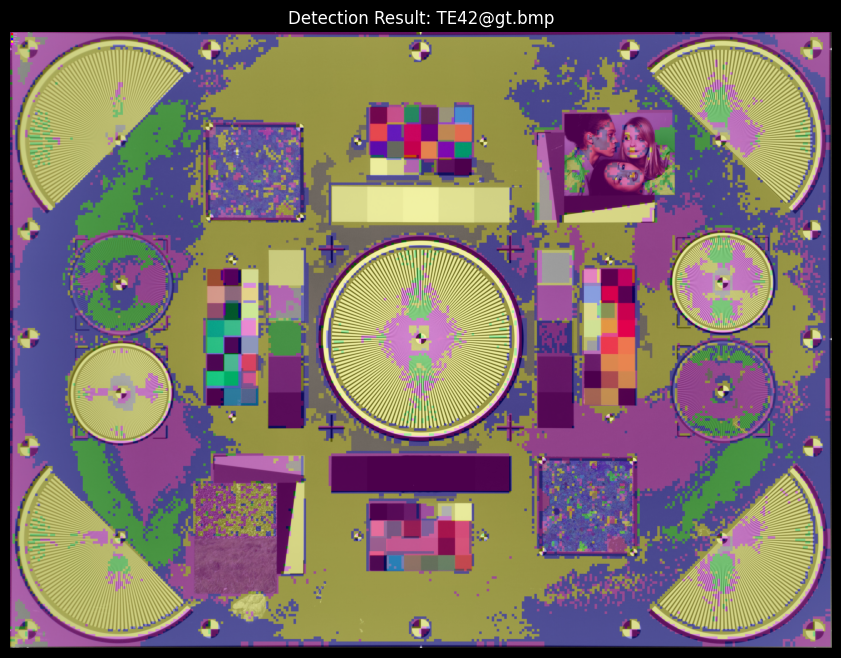

💾 Result saved as detection_result.png


In [11]:
if __name__ == "__main__":
    run_analysis("/home/inonzr/datasets/samsung/TE42@gt.bmp")
    pass